In [1]:
# Calculate hyperfine line shift and broadening

In [2]:
import sys
sys.path.append("../src/")
sys.path.append("../src/AtomicTrit")

In [82]:
from AtomicTrit import spinexchange
from AtomicTrit import potentials
from AtomicTrit import dipolelosses
from AtomicTrit import constants
from AtomicTrit import elastic
import numpy as np
import pylab as plt
import pandas as pd 

from AtomicTrit import dipolelosses
from AtomicTrit.dipolelosses import DipoleChannels
from AtomicTrit import spinexchange
from AtomicTrit.spinexchange import SpinExChannels

from cycler import cycler
from matplotlib import pyplot as plt

plt.rcParams['axes.prop_cycle'] = cycler('color', plt.get_cmap('Dark2').colors)


from spinexchange import SpinExChannels

In [7]:
def Lambda_0_DIS(rhos, p, l, mu):
    # l even
    delta_l_1 = elastic.GetPhaseShift(rhos, p, l, mu, potential=potentials.Silvera_Triplet, how_to_int='Radau')
    delta_l_0 = elastic.GetPhaseShift(rhos, p, l, mu, potential=potentials.Silvera_Singlet, how_to_int='Radau')
    return np.pi/(2*k**2) * (2*l+1)*np.sin(2*delta_l_1 - 2*delta_l_0)

def Lambda_1_DIS(rhos, p, l, mu):
    return 0
def Lambda_2_DIS(rhos, p, l, mu):
    return 0

def Sigma_0_DIS(rhos, p, l, mu):
    return 0

def Sigma_1_DIS(rhos, p, l, mu):
    delta_l_1 = elastic.GetPhaseShift(rhos, p, l, mu, potential=potentials.Silvera_Triplet, how_to_int='Radau')
    delta_l_0 = elastic.GetPhaseShift(rhos, p, l, mu, potential=potentials.Silvera_Singlet, how_to_int='Radau')
    return np.pi/(k**2) * (-1)**l (2*l+1)*np.sin(delta_l_0 - delta_l_1)**2

def Sigma_2_DIS(rhos, p, l, mu):
    # l odd
    delta_l_1 = elastic.GetPhaseShift(rhos, p, l, mu, potential=potentials.Silvera_Triplet, how_to_int='Radau')
    delta_l_0 = elastic.GetPhaseShift(rhos, p, l, mu, potential=potentials.Silvera_Singlet, how_to_int='Radau')
    return np.pi/(k**2) * (2*l+1)*np.sin(delta_l_0 - delta_l_1)**2

In [8]:
#Calculate higher partial wave elastic cross sections
k_eV  = np.linspace(1e-4, 4*constants.hcInEVAngstrom, 20)
k_A = k_eV / constants.hcInEVAngstrom

r0       = 1e-9
intlimit = 100 * constants.BohrInAng/constants.hcInEVAngstrom
rhos = np.linspace(r0, intlimit, 10)

muH=constants.HydrogenConstants.mu
muT=constants.TritiumConstants.mu

even_ls = np.arange(0, 16, 2)
odd_ls = np.arange(1, 17, 2)
ls = np.arange(0, 16, 1)

Lambda_0_DIS_l = {}
Lambda_0_DIS_total = np.zeros_like(k_A)   # activate if you want Σ_l


for l in even_ls:
    lambda_T_partial = np.array([Lambda_0_DIS(rhos, k, l, muH)
        for k in k_eV
    ])
    Lambda_0_DIS_l[l] = lambda_T_partial
    Lambda_0_DIS_total   += Lambda_0_DIS_l[l]

KeyboardInterrupt: 

In [ ]:


plt.figure(figsize=(5,4.7), dpi=250)
for l in Lambda_0_DIS_l.keys():
    plt.plot(k_A, np.array(Lambda_0_DIS_l[l])* constants.hcInEVAngstrom**2*constants.BohrInAng**-2,alpha=0.5,label=r'$\mathtt{l}$='+str(l))
plt.plot(k_A, np.array(Lambda_0_DIS_total) * constants.hcInEVAngstrom**2*constants.BohrInAng**-2, label="Total",color='black')
plt.plot(k[0:-5],XS_smooth[0:-5]*constants.BohrInAng**-2, ':',label="Al-Maaitah",color='dimgrey',linewidth=4)
plt.xlabel(r'Relative momentum $k\;[\mathrm{\AA}^{-1}]$')
plt.ylabel(r'Total cross-section, $\sigma$ (a.u.)$^2$')
plt.xlim(0, 4)
plt.ylim(0, 800)
plt.title("T-T triplet scattering")
plt.legend(ncol=2)
# plt.savefig("./Plots/TTElastic.png",dpi=250,bbox_inches='tight')

In [75]:
# data from stoof 1988
Stoof1988_spin_exchange = pd.read_csv('Tables/Stoof1988_spin_exchange.csv')
Stoof1988_dd_ = pd.read_csv('Tables/Stoof1988_dd_.csv')


,Unnamed: 0,T_bd_aa,G_bd_aa,T_bd_cc,G_bd_cc,T_cc_aa,G_cc_aa
0,0,0.000581,3.100707e-12,0.000581,2.654867e-13,0.000581,3.100707e-12
1,1,0.200929,4.249117e-12,0.101045,2.619469e-12,0.200929,4.249117e-12
2,2,0.300232,4.452297e-12,0.021487,1.345133e-12,0.300232,4.452297e-12
3,3,0.400116,4.558304e-12,0.040070,1.787611e-12,0.400116,4.558304e-12
4,4,0.498839,4.628975e-12,0.059814,2.123894e-12,0.498839,4.628975e-12
5,5,0.020325,3.321555e-12,0.080720,2.398230e-12,0.020325,3.321555e-12
6,6,0.040650,3.507067e-12,0.120790,2.787611e-12,0.040650,3.507067e-12
7,7,0.060976,3.657244e-12,0.140534,2.946903e-12,0.060976,3.657244e-12
8,8,0.080720,3.780919e-12,0.160279,3.079646e-12,0.080720,3.780919e-12
9,9,0.101626,3.895760e-12,0.179443,3.194690e-12,0.101626,3.895760e-12


In [104]:
B_value  = 1e-5
potT     = potentials.Silvera_Triplet
potS     = potentials.Kolos_Singlet2_VDW

T_values = np.linspace(1e-3, 0.5, 50)


GVsT_H=[]
GVsT_T=[]

for c in SpinExChannels:
    
    GsH=[]
    GsT=[]

    for T in T_values:
        GsH.append(spinexchange.GetGFactor(c,  B_value, constants.HydrogenConstants(), T, potT,potS,np.linspace(1e-9,0.75,20000)))
        GsT.append(spinexchange.GetGFactor(c,  B_value, constants.TritiumConstants(), T, potT,potS,np.linspace(1e-9,0.75,20000)))
    GVsT_H.append(np.array(GsH))
    GVsT_T.append(np.array(GsT))


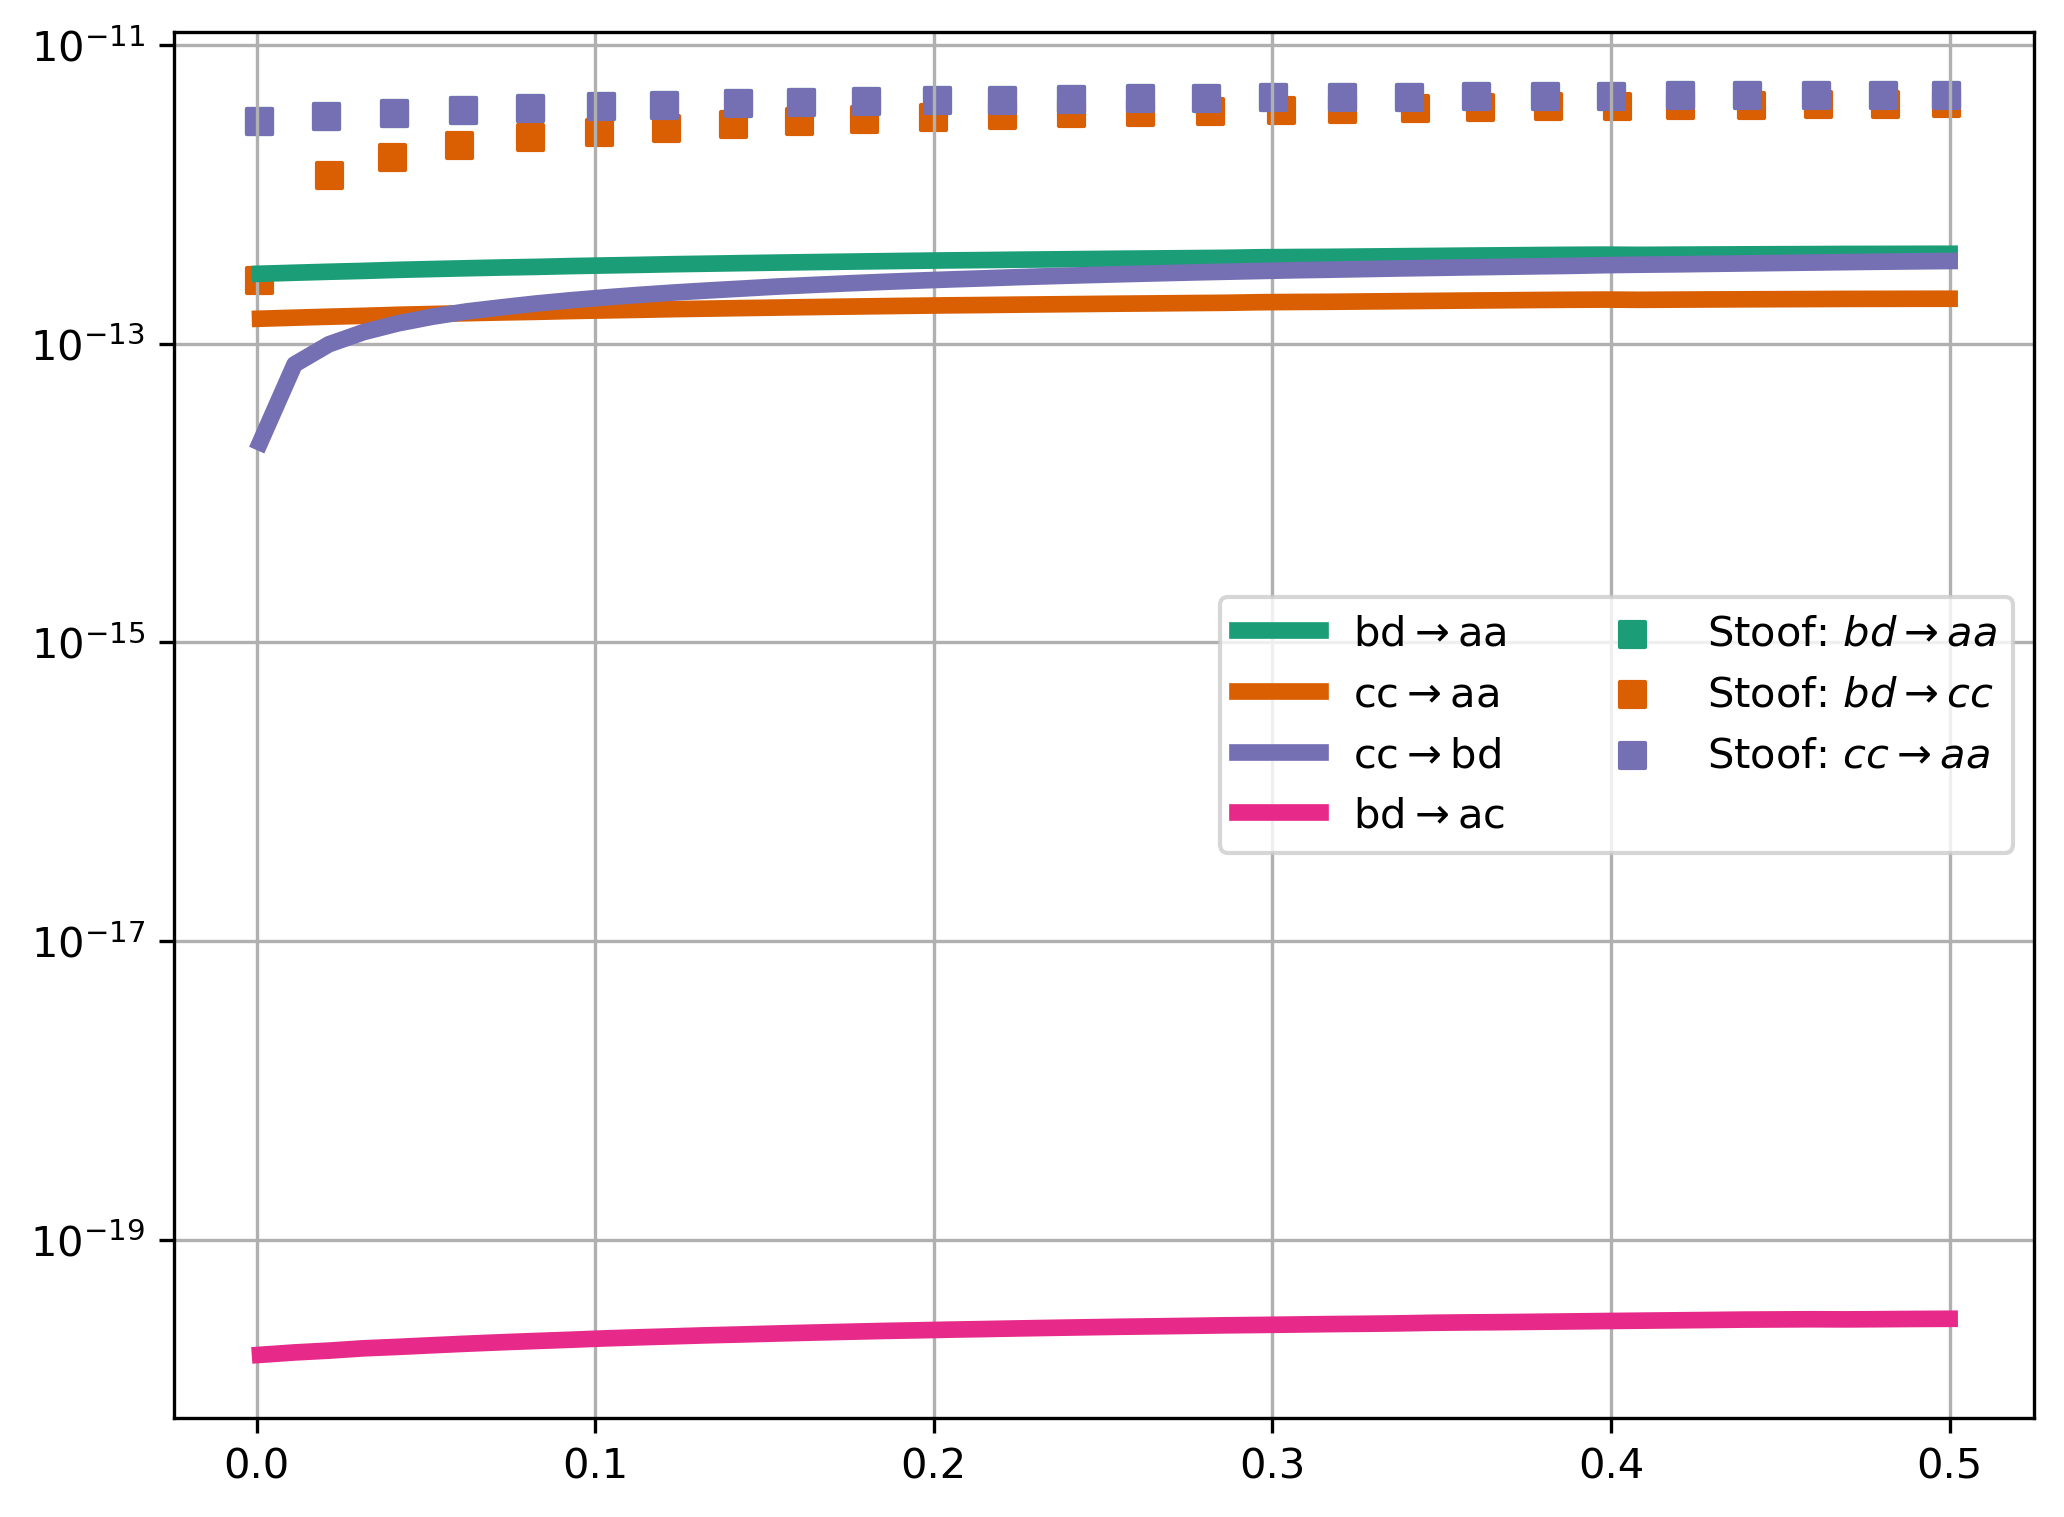

In [105]:
# Comparison of Stoof1988 data with caclulated

channels = [r'bd$\rightarrow$aa',r'cc$\rightarrow$aa',r'cc$\rightarrow$bd',r'bd$\rightarrow$ac']
plt.figure(figsize = (8,6), dpi = 300)
for i,ch in enumerate(GVsT_H):
    # plt.plot(dipolelosses.E_com(T_values), ch, label = channels[i],lw = 4)
    plt.plot(T_values, ch, label = channels[i],lw = 4)

# for i,ch in enumerate(GVsT_T):
#     plt.plot(dipolelosses.E_com(T_values), ch, label = channels[i],lw = 4, ls = '--')


plt.scatter(Stoof1988_spin_exchange['T_bd_aa'], Stoof1988_spin_exchange['G_bd_aa'], marker = 's', label = r'Stoof: ${bd \rightarrow aa}$')
plt.scatter(Stoof1988_spin_exchange['T_bd_cc'], Stoof1988_spin_exchange['G_bd_cc'], marker = 's', label = r'Stoof: ${bd \rightarrow cc}$')
plt.scatter(Stoof1988_spin_exchange['T_cc_aa'], Stoof1988_spin_exchange['G_cc_aa'], marker = 's', label = r'Stoof: ${cc \rightarrow aa}$')
plt.yscale('log')
plt.grid()
plt.legend(ncol=2)

In [106]:
B = 1e-5 

T_values = np.linspace(1e-3, 0.5, 10)



GVsB_HDip=[]
# GVsB_TDip=[]

for c in DipoleChannels:
    Gs=[]
    for T in T_values:
        Gs.append(dipolelosses.GetGFactor(
            c,  B, constants.HydrogenConstants, T, potentials.Silvera_Triplet,rhos=np.linspace(1e-9,0.75,2000),lin=0,lout=2)
        )
    GVsB_HDip.append(np.array(Gs))
    # Gs=[]

    # for T in T_values:
    #     Gs.append(dipolelosses.GetGFactor(
    #         c,  B, constants.TritiumConstants, T, potentials.Silvera_Triplet,rhos=np.linspace(1e-9,0.75,2000),lin=0,lout=2)
    #     )
    # GVsB_TDip.append(np.array(Gs))

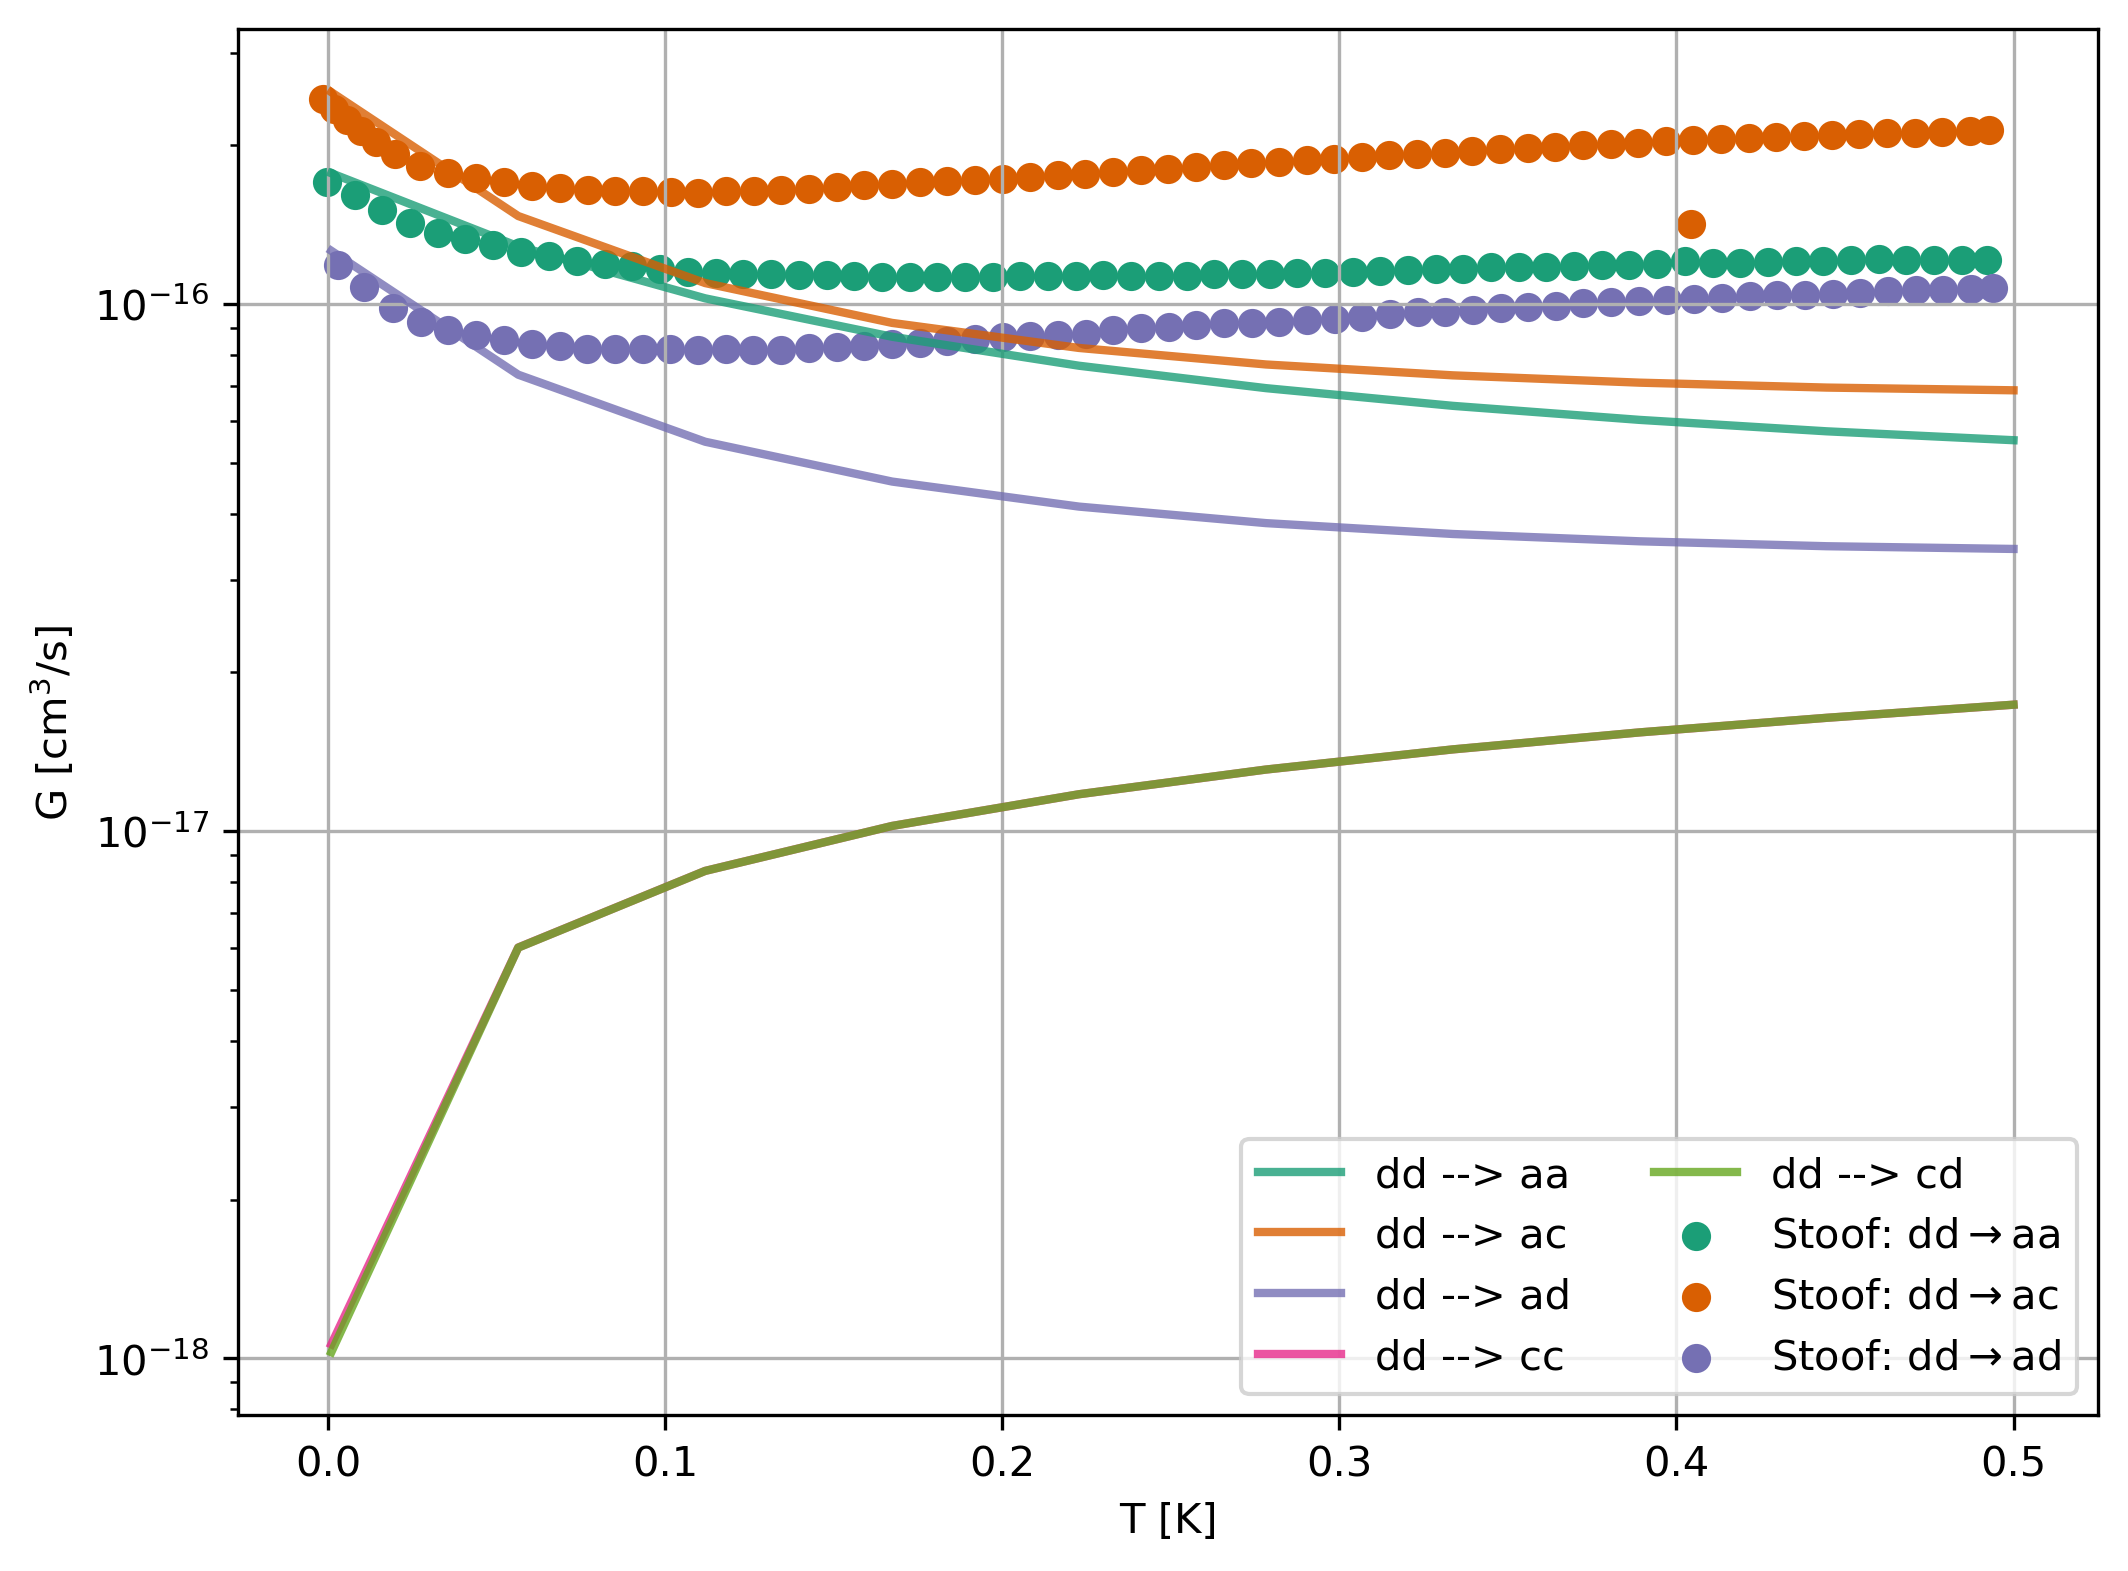

In [107]:
# comparison Stoof1988 dd-> ,with calculated 

plt.figure(figsize = (8,6), dpi = 300)

c=0
for ci in range(0,len(DipoleChannels)):
    Label='dd --> '+str(DipoleChannels[ci]['alphaprime'])+str(DipoleChannels[ci]['betaprime'])
    plt.plot(T_values, GVsB_HDip[ci],label=Label,color=colors[c],linewidth=2,alpha=0.8)
    c=c+1
    plt.semilogy()


plt.scatter(Stoof1988_dd_['T_dd_aa'], Stoof1988_dd_['G_dd_aa'], label = r'Stoof: dd$\rightarrow$aa')
plt.scatter(Stoof1988_dd_['T_dd_ac'], Stoof1988_dd_['G_dd_ac'], label = r'Stoof: dd$\rightarrow$ac')
plt.scatter(Stoof1988_dd_['T_dd_ad'], Stoof1988_dd_['G_dd_ad'], label = r'Stoof: dd$\rightarrow$ad')

plt.ylabel(r'G [cm$^3$/s]')
plt.xlabel('T [K]')
plt.yscale('log')
plt.grid()
plt.legend(ncol=2)